# PS1 V2 — Dynamic Human–Automation Allocation

**Research question:** When is it worth accepting a current performance cost from manual control in order to preserve human capability for future periods when automation may become unavailable?

This notebook implements the same synthetic decision environment as the latest **Stay in the Loop** Hugging Face game, but its purpose is different:

- the game makes the trade-off visible through realized emergencies and realized losses;
- this notebook computes the **normative expected-loss benchmark** before those random outcomes are known.

> **Important:** The capability dynamics are synthetic model assumptions for a computational demonstration. They are not empirical estimates of real human skill, and simulated outputs are not evidence of human behavior.


## 1. Model

There are $T=12$ rounds. At the beginning of each round, automation is unavailable with probability $q$.

Human task-specific capability at round $t$ is $s_t$. Automation succeeds with probability $p_A$.

If automation is available, the decision is

$$
a_t \in \{A,H\},
$$

where $A$ means **use automation** and $H$ means **practice manual control**.

If automation is unavailable, human control is forced.

Failure produces loss $L$. Therefore, expected one-round loss is

$$
c_A=(1-p_A)L
$$

under automation and

$$
c_H(s_t)=(1-s_t)L
$$

under human control.

Current allocation also changes future human capability:

$$
s_{t+1}=
\begin{cases}
\max(s_{\min},\,s_t-d), & a_t=A,\\[4pt]
\min(s_{\max},\,s_t+g), & a_t=H,
\end{cases}
$$

where $d$ is capability decay after automation use and $g$ is capability recovery after manual practice.

The benchmark therefore evaluates both **current performance** and **future backup capability**.


In [ ]:
from functools import lru_cache
import pandas as pd
import matplotlib.pyplot as plt

# Same baseline parameters as the latest Hugging Face game
T = 12
p_A = 0.95
L = 100
delta = 1.0

s0 = 0.88
decay = 0.04
recovery = 0.04
s_min, s_max = 0.56, 0.92

Q_VALUES = [0.10, 0.30]

def r2(x):
    return round(float(x) + 1e-12, 2)

def next_skill(s, action, decay_value=decay):
    change = recovery if action == "H" else -decay_value
    return r2(min(s_max, max(s_min, s + change)))

def expected_current_loss(s, action):
    p_success = p_A if action == "A" else s
    return (1 - p_success) * L

print("Automation expected loss:", expected_current_loss(s0, "A"))
print("Initial manual expected loss:", expected_current_loss(s0, "H"))


Automation expected loss: 5.000000000000004
Initial manual expected loss: 12.0


## 2. Dynamic-programming benchmark

The important change from the earlier notebook is that **emergencies can occur in every round**, matching the revised game.

Let $V_t(s)$ denote minimum expected cumulative loss from round $t$ onward.

If automation is unavailable, human control is forced:

$$
C_t^{F}(s)
=
c_H(s)
+
\delta V_{t+1}(s_H'),
$$

where $s_H'$ is capability after manual use.

If automation is available, the benchmark compares

$$
C_t^{A}(s)
=
c_A
+
\delta V_{t+1}(s_A')
$$

with

$$
C_t^{H}(s)
=
c_H(s)
+
\delta V_{t+1}(s_H').
$$

Before availability is known, the Bellman equation is

$$
V_t(s)
=
q\,C_t^{F}(s)
+
(1-q)\min\left\{C_t^{A}(s),C_t^{H}(s)\right\}.
$$

This is the computational version of the proposal's central trade-off: manual practice can be worse **today** but valuable because it preserves capability for future forced intervention.


In [ ]:
def solve_dp(q, decay_value=decay):
    @lru_cache(None)
    def V(t, s):
        s = r2(s)
        if t > T:
            return 0.0

        s_h = next_skill(s, "H", decay_value)
        s_a = next_skill(s, "A", decay_value)

        forced_h = expected_current_loss(s, "H") + delta * V(t + 1, s_h)
        cost_a = expected_current_loss(s, "A") + delta * V(t + 1, s_a)
        cost_h = expected_current_loss(s, "H") + delta * V(t + 1, s_h)

        return q * forced_h + (1 - q) * min(cost_a, cost_h)

    def policy(t, s):
        s = r2(s)
        cost_a = expected_current_loss(s, "A") + delta * V(
            t + 1, next_skill(s, "A", decay_value)
        )
        cost_h = expected_current_loss(s, "H") + delta * V(
            t + 1, next_skill(s, "H", decay_value)
        )
        return "H" if cost_h < cost_a else "A"

    return V, policy


## 3. What does the optimal policy look like?

A single fixed action sequence is not enough because emergencies change the capability path. The optimal decision is therefore a **state-dependent policy**.

The table below shows the benchmark action when automation is available for combinations of:

- round $t$,
- current human capability $s_t$,
- emergency risk $q$.

This is more faithful to the game than following only one hypothetical no-emergency path.


In [ ]:
skill_grid = [0.56, 0.64, 0.72, 0.80, 0.88, 0.92]

rows = []
for q in Q_VALUES:
    V, policy = solve_dp(q)
    for t in range(1, T + 1):
        for s in skill_grid:
            rows.append({
                "q": q,
                "round": t,
                "human_capability": s,
                "optimal_action_if_available":
                    "Manual" if policy(t, s) == "H" else "Automation"
            })

policy_table = pd.DataFrame(rows)
policy_table.head(24)


,q,round,human_capability,optimal_action_if_available
0,0.1,1,0.56,Automation
1,0.1,1,0.64,Automation
2,0.1,1,0.72,Automation
3,0.1,1,0.80,Automation
4,0.1,1,0.88,Manual
5,0.1,1,0.92,Manual
6,0.1,2,0.56,Automation
7,0.1,2,0.64,Automation
8,0.1,2,0.72,Automation
9,0.1,2,0.80,Automation


## 4. Main comparison: expected voluntary manual practice

Because emergencies are random, the number of voluntary manual-practice rounds is also random.

The relevant benchmark is therefore not simply the number of $H$'s on one path. Instead, define

$$
M_t(s)
$$

as the **expected number of future voluntary manual choices** under the optimal policy.

Forced manual control during an emergency is not counted as voluntary practice.

The recursion averages over both possibilities in every round:

$$
M_t(s)
=
q\,M_{t+1}(s_H')
+
(1-q)
\left[
\mathbf{1}\{\pi_t(s)=H\}
+
M_{t+1}(s_{\pi}')
\right].
$$

This gives a direct test of the proposal's prediction:

$$
q \uparrow
\quad\Rightarrow\quad
\text{optimal voluntary manual practice} \uparrow.
$$


In [ ]:
def optimal_summary(q, decay_value=decay):
    V, policy = solve_dp(q, decay_value)

    @lru_cache(None)
    def expected_manual_count(t, s):
        s = r2(s)
        if t > T:
            return 0.0

        action = policy(t, s)
        forced_next = expected_manual_count(
            t + 1, next_skill(s, "H", decay_value)
        )
        chosen_next = expected_manual_count(
            t + 1, next_skill(s, action, decay_value)
        )

        return (
            q * forced_next
            + (1 - q) * (
                (1 if action == "H" else 0)
                + chosen_next
            )
        )

    return {
        "q": q,
        "optimal_expected_loss": V(1, s0),
        "expected_voluntary_manual_rounds": expected_manual_count(1, s0),
        "first_action_if_available":
            "Manual" if policy(1, s0) == "H" else "Automation"
    }

summary = pd.DataFrame([optimal_summary(q) for q in Q_VALUES])
summary


,q,optimal_expected_loss,expected_voluntary_manual_rounds,first_action_if_available
0,0.1,87.59977,2.7,Manual
1,0.3,95.88400,5.6,Manual


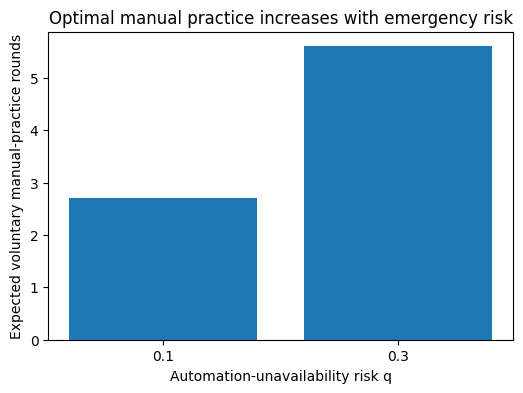

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(
    summary["q"].astype(str),
    summary["expected_voluntary_manual_rounds"]
)
plt.xlabel("Automation-unavailability risk q")
plt.ylabel("Expected voluntary manual-practice rounds")
plt.title("Optimal manual practice increases with emergency risk")
plt.show()


## 5. Myopic baseline

The dynamic benchmark should be compared with a policy that ignores future capability.

A **myopic** decision chooses only the action with the lower current expected loss:

$$
\pi^{\text{myopic}}(s)
=
\arg\min_{a\in\{A,H\}} c(s,a).
$$

With the baseline parameters, automation has a 95% success rate while human capability is capped below 95%. Therefore, whenever automation is available, the myopic policy chooses automation.

This comparison isolates the value created by the intertemporal mechanism:

- **myopic policy:** current performance only;
- **dynamic policy:** current performance + future backup capability.


In [ ]:
def myopic_action(s):
    return (
        "H"
        if expected_current_loss(s, "H") < expected_current_loss(s, "A")
        else "A"
    )

myopic_demo = pd.DataFrame({
    "human_capability": skill_grid,
    "myopic_action": [
        "Manual" if myopic_action(s) == "H" else "Automation"
        for s in skill_grid
    ]
})
myopic_demo


,human_capability,myopic_action
0,0.56,Automation
1,0.64,Automation
2,0.72,Automation
3,0.80,Automation
4,0.88,Automation
5,0.92,Automation


## 6. Sensitivity check: capability decay

The proposal should not depend on one arbitrary decay value. A sensitivity analysis varies the amount of capability lost after automation use.

For each pair $(q,d)$, the notebook recomputes the entire dynamic program and reports expected voluntary manual practice.

This asks whether the qualitative result is robust:

$$
\text{faster capability decay}
\quad\Rightarrow\quad
\text{greater value of preserving manual capability},
$$

especially when future automation unavailability is sufficiently important.


In [ ]:
sensitivity_rows = []

for q in Q_VALUES:
    for d in [0.01, 0.02, 0.03, 0.04, 0.05]:
        result = optimal_summary(q, decay_value=d)
        sensitivity_rows.append({
            "q": q,
            "decay": d,
            "expected_voluntary_manual_rounds":
                result["expected_voluntary_manual_rounds"],
            "optimal_expected_loss":
                result["optimal_expected_loss"]
        })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity


,q,decay,expected_voluntary_manual_rounds,optimal_expected_loss
0,0.1,0.01,0.0000,71.932688
1,0.1,0.02,0.0000,77.747353
2,0.1,0.03,0.9000,83.542919
3,0.1,0.04,2.7000,87.599770
4,0.1,0.05,4.5000,89.985399
5,0.3,0.01,0.7000,82.599516
6,0.3,0.02,1.2488,89.155865
7,0.3,0.03,3.4370,94.507240
8,0.3,0.04,5.6000,95.884000
9,0.3,0.05,6.3000,96.598000


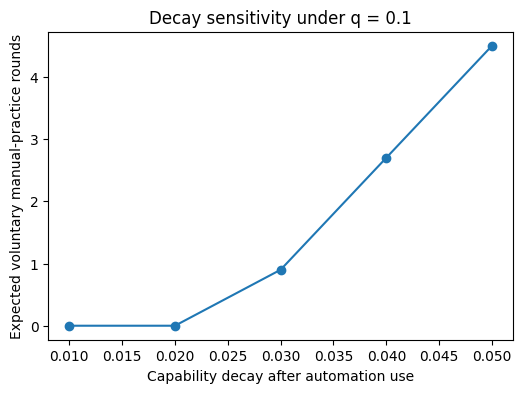

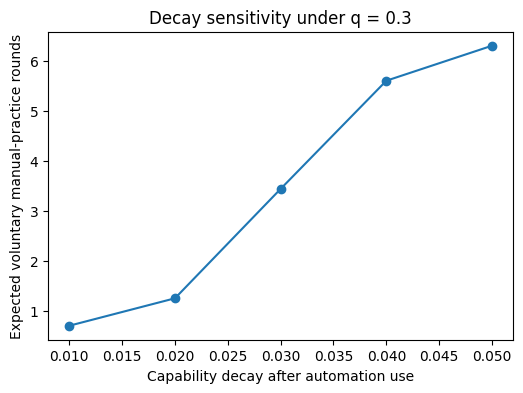

In [ ]:
for q, group in sensitivity.groupby("q"):
    plt.figure(figsize=(6, 4))
    plt.plot(
        group["decay"],
        group["expected_voluntary_manual_rounds"],
        marker="o"
    )
    plt.xlabel("Capability decay after automation use")
    plt.ylabel("Expected voluntary manual-practice rounds")
    plt.title(f"Decay sensitivity under q = {q}")
    plt.show()


## 7. Connection to the Hugging Face game

The notebook and game use the same conceptual model but answer different questions.

### Hugging Face game

The game shows one **realized stochastic trajectory**:

1. an emergency may or may not occur;
2. the player chooses control when automation is available;
3. the chosen controller may succeed or fail;
4. failures create realized loss;
5. capability changes and affects later rounds.

This makes the intertemporal trade-off psychologically visible.

### Colab benchmark

The notebook does not rely on one lucky or unlucky trajectory. It integrates over possible future emergencies and failures to calculate the policy with the lowest **expected cumulative loss**.

Therefore,

$$
\text{realized game loss}
\neq
\text{policy quality}.
$$

A player could obtain a low realized loss by luck even with a poor policy. The dynamic program provides the normative comparison needed to evaluate repeated allocation decisions.


## 8. Interpretation and limitations

The computational result is a **model implication**, not evidence about actual human behavior.

The notebook establishes whether, under the assumed capability dynamics, preserving human capability can rationally justify manual practice even when automation has better immediate performance.

The later behavioral study would ask whether people respond to the same intertemporal incentives:

$$
\text{Do humans increase voluntary manual practice when } q \text{ increases?}
$$

and whether the size and timing of that adjustment resemble the dynamic benchmark.

The largest empirical limitation is the transition function for human capability. The current values for decay and recovery are imposed synthetic parameters. A stronger future study would estimate

$$
s_{t+1}=f(s_t,a_t)
$$

from task-specific human performance and then recompute the benchmark using those estimated dynamics.
